## 1. Data Audit

The objective of this phase is to understand the structure and quality
of the training and test datasets before performing EDA, feature
engineering, validation, or model training.

### Audit objectives

1. Dataset structure
2. Data types
3. Missing values
4. Cardinality
5. Duplicate observations
6. Train/test consistency
7. Target variable audit


In [277]:
# Import and load data
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Sum of Train duplicates", train.duplicated().sum())
train

Train shape: (6818, 13)
Test shape : (1705, 12)
Sum of Train duplicates 0


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6813,row_08518,PRD-V56VKT,9.201,Regular,0.2851,Fruits and Vegetables,136.57,STORE-JOR,34,NaN,Tier_3,Corner Shop,276.50
6814,row_08519,PRD-S1AWP0,15.770,Low Fat,0.1193,FROZEN FOODS,74.03,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1265.63
6815,row_08520,PRD-NCP2VI,17.665,Low Fat,0.0182,Health and Hygiene,234.87,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,6254.55
6816,row_08521,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1658.06


In [278]:
# Inspect Columns
print("Train Columns")

for i, col in enumerate(train.columns, start=1):
    print(f"{i:2}. {col}")


print("\nTest Columns")

for i, col in enumerate(test.columns, start=1):
    print(f"{i:2}. {col}")

Train Columns
 1. id
 2. product_code
 3. product_weight_kg
 4. fat_content
 5. shelf_visibility
 6. product_category
 7. product_price
 8. store_code
 9. store_age_years
10. store_size
11. store_location_tier
12. store_format
13. total_sales

Test Columns
 1. id
 2. product_code
 3. product_weight_kg
 4. fat_content
 5. shelf_visibility
 6. product_category
 7. product_price
 8. store_code
 9. store_age_years
10. store_size
11. store_location_tier
12. store_format


In [279]:
# Basic Structure
print("Train Info")
train.info()

print("\nTest Info")
test.info()

Train Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB

Test Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 en

In [280]:
# Data Type Audit
dtype_audit = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing": train.isna().sum(),
    "missing_pct": (train.isna().mean() * 100).round(2),
    "unique_values": train.nunique(dropna=True)
})

dtype_audit

,dtype,missing,missing_pct,unique_values
id,object,0,0.00,6818
product_code,object,0,0.00,1555
product_weight_kg,float64,1225,17.97,4675
fat_content,object,0,0.00,2
shelf_visibility,float64,0,0.00,1732
product_category,object,0,0.00,48
product_price,float64,0,0.00,5818
store_code,object,0,0.00,10
store_age_years,int64,0,0.00,9
store_size,object,1919,28.15,3


In [281]:
#Missing-value Audit
missing_audit = pd.DataFrame(
    {
    "train_missing": train.isna().sum(),
    "train_missing_pct": (train.isna().mean() * 100).round(2),
    "test_missing": test.isna().sum(),
    "test_missing_pct": (test.isna().mean() * 100).round(2)
    }
)

missing_audit = missing_audit.sort_values(
    "train_missing",
    ascending=False
)

missing_audit

,train_missing,train_missing_pct,test_missing,test_missing_pct
store_size,1919,28.15,491.0,28.80
product_weight_kg,1225,17.97,306.0,17.95
fat_content,0,0.00,0.0,0.00
id,0,0.00,0.0,0.00
product_category,0,0.00,0.0,0.00
product_code,0,0.00,0.0,0.00
product_price,0,0.00,0.0,0.00
shelf_visibility,0,0.00,0.0,0.00
store_age_years,0,0.00,0.0,0.00
store_code,0,0.00,0.0,0.00


In [282]:
#Total Missing Values
print("Total missing cells:")

print("Train:", train.isna().sum().sum())
print("Test :", test.isna().sum().sum())

Total missing cells:
Train: 3144
Test : 797


In [283]:
# Unique Value Audit
cardinality = pd.DataFrame(
    {
    "dtype": train.dtypes.astype(str),
    "n_unique": train.nunique(dropna=True),
    "unique_pct": (train.nunique(dropna=True) / len(train) * 100).round(2)
    }
    )

cardinality = cardinality.sort_values("n_unique", ascending = False)

cardinality

,dtype,n_unique,unique_pct
id,object,6818,100.00
total_sales,float64,6776,99.38
product_price,float64,5818,85.33
product_weight_kg,float64,4675,68.57
shelf_visibility,float64,1732,25.40
product_code,object,1555,22.81
product_category,object,48,0.70
store_code,object,10,0.15
store_age_years,int64,9,0.13
store_format,object,4,0.06


In [284]:
# Exact duplicates
print("Exact Duplicate Rows:")

print("Train:", train.duplicated().sum())
print("Test :", test.duplicated().sum())

Exact Duplicate Rows:
Train: 0
Test : 0


In [285]:
# Product Store duplicates
pair_columns = ["product_code", "store_code"]

train_pair_duplicates = train.duplicated(subset=pair_columns).sum()

test_pair_duplicates = test.duplicated(
    subset=pair_columns
).sum()

print("Duplicate Product-Store Combinations")

print("Train:", train_pair_duplicates)
print("Test :", test_pair_duplicates)

Duplicate Product-Store Combinations
Train: 0
Test : 0


In [286]:
# Identify Categorical Columns
categorical_columns = train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['id', 'product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']


In [287]:
# Compare Categorical Domains and discover if categories exist in test but not train
for column in categorical_columns:

    train_values = set(train[column].dropna().unique())
    test_values = set(test[column].dropna().unique())

    test_only_values = test_values - train_values

    print(f"\n{column}")
    print("Train unique values:", len(train_values))
    print("Test unique values :", len(test_values))
    print("Test-only values   :", test_only_values)


id
Train unique values: 6818
Test unique values : 1705
Test-only values   : {'row_01583', 'row_06145', 'row_02418', 'row_01725', 'row_06061', 'row_04416', 'row_02834', 'row_00684', 'row_01064', 'row_07354', 'row_00416', 'row_08483', 'row_01209', 'row_07003', 'row_00698', 'row_00659', 'row_06651', 'row_02536', 'row_06371', 'row_03517', 'row_02940', 'row_04831', 'row_02294', 'row_03996', 'row_04024', 'row_05965', 'row_02133', 'row_05246', 'row_01357', 'row_06355', 'row_00499', 'row_08204', 'row_02508', 'row_05349', 'row_03926', 'row_06150', 'row_06696', 'row_01621', 'row_06047', 'row_06945', 'row_04122', 'row_00405', 'row_04419', 'row_06809', 'row_05146', 'row_01119', 'row_00875', 'row_00905', 'row_00826', 'row_01693', 'row_04226', 'row_05883', 'row_03259', 'row_02584', 'row_04737', 'row_04166', 'row_05406', 'row_03006', 'row_07045', 'row_05870', 'row_03715', 'row_04799', 'row_07577', 'row_00115', 'row_05831', 'row_06248', 'row_06915', 'row_06505', 'row_05371', 'row_08075', 'row_00269',

In [288]:
# Target Statistics
target = "total_sales"

print("TARGET:", target)
display(train[target].describe().to_frame().T)

TARGET: total_sales


,count,mean,std,min,25%,50%,75%,max
total_sales,6818.0,2174.756574,1697.894956,32.7,834.7925,1790.89,3092.5875,12996.82


In [289]:
# Target Validity
print("Missing target values :", train[target].isna().sum())
print("Zero target values    :", (train[target] == 0).sum())
print("Negative target values:", (train[target] < 0).sum())
print("Unique target values  :", train[target].nunique())

Missing target values : 0
Zero target values    : 0
Negative target values: 0
Unique target values  : 6776


In [290]:
# Target Quantiles
target_quantiles = train[target].quantile(
    [ 0.00, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

target_quantiles

0.00       32.7000
0.01       81.2017
0.05      188.1190
0.10      342.0420
0.25      834.7925
0.50     1790.8900
0.75     3092.5875
0.90     4557.8410
0.95     5557.1910
0.99     7261.3893
1.00    12996.8200
Name: total_sales, dtype: float64

In [291]:
# Dataset Contract
target = "total_sales"

# Target exists only in train
assert target in train.columns
assert target not in test.columns

# Train and test predictors must match
train_features = set(train.columns) - {target}
test_features = set(test.columns)

assert train_features == test_features

# IDs should be unique
assert train["id"].is_unique
assert test["id"].is_unique

# Target should not contain missing values
assert train[target].notna().all()

print("Target correctly identified.")
print("Train/test predictor columns match.")
print("Train IDs are unique.")
print("Test IDs are unique.")
print("Training target contains no missing values.")
print("\nDataset Contract Passed.")

Target correctly identified.
Train/test predictor columns match.
Train IDs are unique.
Test IDs are unique.
Training target contains no missing values.

Dataset Contract Passed.


In [292]:
# Category integrity audit

category_columns = [
    "fat_content",
    "product_category",
    "store_code",
    "store_size",
    "store_location_tier",
    "store_format",
]

for col in category_columns:
    print(f"{col}")

    print("\nTrain:")
    display(train[col].value_counts(dropna=False).to_frame("count"))

    print("\nTest:")
    display(test[col].value_counts(dropna=False).to_frame("count"))

fat_content

Train:


,count
fat_content,
Low Fat,4425
Regular,2393



Test:


,count
fat_content,
Low Fat,1092
Regular,613


product_category

Train:


...

,count
store_location_tier,
Tier_3,673
Tier_2,553
Tier_1,479


store_format

Train:


,count
store_format,
Standard Supermarket,4462
Corner Shop,866
Flagship Hypermarket,748
Superstore,742



Test:


,count
store_format,
Standard Supermarket,1115
Corner Shop,217
Flagship Hypermarket,187
Superstore,186


In [293]:
# Check for possible whitespace/case inconsistencies

for col in [
    "fat_content",
    "product_category",
    "store_size",
    "store_location_tier",
    "store_format",
]:
    values = pd.concat(
        [train[col], test[col]],
        ignore_index=True
    ).dropna().astype(str)

    normalized = values.str.strip().str.lower()

    variants = pd.DataFrame({
        "raw": values,
        "normalized": normalized
    }).drop_duplicates()

    grouped = variants.groupby("normalized")["raw"].agg(list)

    inconsistent = grouped[grouped.str.len() > 1]

    print(f"{col}")

    if len(inconsistent) == 0:
        print("No obvious case/whitespace variants found.")
    else:
        display(inconsistent.to_frame("variants"))

fat_content
No obvious case/whitespace variants found.
product_category


,variants
normalized,
baking goods,"[baking goods, BAKING GOODS, Baking Goods]"
breads,"[Breads, BREADS, breads]"
breakfast,"[Breakfast, breakfast, BREAKFAST]"
canned,"[Canned, CANNED, canned]"
dairy,"[Dairy, dairy, DAIRY]"
frozen foods,"[Frozen Foods, frozen foods, FROZEN FOODS]"
fruits and vegetables,"[Fruits and Vegetables, fruits and vegetables,..."
hard drinks,"[Hard Drinks, hard drinks, HARD DRINKS]"
health and hygiene,"[HEALTH AND HYGIENE, Health and Hygiene, healt..."


store_size
No obvious case/whitespace variants found.
store_location_tier
No obvious case/whitespace variants found.
store_format
No obvious case/whitespace variants found.


In [294]:
# Product code structure audit

print("Number of unique product codes:")
print(train["product_code"].nunique())

print("\nSample product codes:")
display(train["product_code"].head(20).to_frame())

print("\nProduct code length distribution:")
display(
    train["product_code"]
    .astype(str)
    .str.len()
    .value_counts()
    .sort_index()
    .to_frame("count")
)

print("\nProduct code prefix distribution:")
display(
    train["product_code"]
    .astype(str)
    .str[:2]
    .value_counts()
    .head(30)
    .to_frame("count")
)

Number of unique product codes:
1555

Sample product codes:


,product_code
0,PRD-PRFP9S
1,PRD-PXXK71
2,PRD-V5MOIJ
3,PRD-UN5Z3J
4,PRD-6RDQYB
5,PRD-E6VA05
6,PRD-MHLD93
7,PRD-EF6Y39
8,PRD-IAZMTU
9,PRD-DH2TA3



Product code length distribution:


,count
product_code,
10,6818



Product code prefix distribution:


,count
product_code,
PR,6818


In [295]:
# Check whether product codes have a stable relationship with product categories

product_category_mapping = (
    train.groupby("product_code")["product_category"]
    .nunique()
)

print("Product codes associated with more than one raw category:")
print((product_category_mapping > 1).sum())

print("\nMaximum number of raw categories associated with one product code:")
print(product_category_mapping.max())

Product codes associated with more than one raw category:
1392

Maximum number of raw categories associated with one product code:
3


In [296]:
# Product-level attribute consistency audit

product_attributes = [
    "product_weight_kg",
    "fat_content",
    "shelf_visibility",
    "product_category",
    "product_price",
]

for col in product_attributes:
    consistency = train.groupby("product_code")[col].nunique(dropna=False)

    print(col)
    print("Products with exactly one unique value:", (consistency == 1).sum())
    print("Products with more than one unique value:", (consistency > 1).sum())
    print("Maximum unique values for one product:", consistency.max())

product_weight_kg
Products with exactly one unique value: 47
Products with more than one unique value: 1508
Maximum unique values for one product: 9
fat_content
Products with exactly one unique value: 1555
Products with more than one unique value: 0
Maximum unique values for one product: 1
shelf_visibility
Products with exactly one unique value: 47
Products with more than one unique value: 1508
Maximum unique values for one product: 9
product_category
Products with exactly one unique value: 163
Products with more than one unique value: 1392
Maximum unique values for one product: 3
product_price
Products with exactly one unique value: 46
Products with more than one unique value: 1509
Maximum unique values for one product: 9


In [297]:
# Number of stores associated with each product

stores_per_product = train.groupby("product_code")["store_code"].nunique()

print("Distribution of number of stores per product:")
display(stores_per_product.value_counts().sort_index().to_frame("number_of_products"))

print("\nMaximum stores observed for one product:", stores_per_product.max())
print("Products appearing in all 10 stores:", (stores_per_product == 10).sum())

Distribution of number of stores per product:


,number_of_products
store_code,
1,46
2,140
3,251
4,394
5,351
6,240
7,97
8,35
9,1



Maximum stores observed for one product: 9
Products appearing in all 10 stores: 0


# Findings & Inferences

The data audit established the structural properties and quality of the
training and test datasets before any transformation, imputation,
encoding, or feature engineering was applied.

## Key Findings

### 1. Dataset structure

- The training set contains 6,818 observations and 13 columns.
- The test set contains 1,705 observations and 12 columns.
- The predictor columns are consistent between train and test.
- Train and test IDs are unique.
- There are no exact duplicate rows.
- There are no duplicate `product_code + store_code` combinations.
- The target variable, `total_sales`, is present only in the training set
  and contains no missing or invalid values.

### 2. Missing data

Missing values are concentrated in two predictors:

- `product_weight_kg`: approximately 18% missing
- `store_size`: approximately 28% missing

The missingness rates are similar between the training and test sets,
suggesting that missing values are part of the dataset structure rather
than an obvious train/test discrepancy.

The missing values will therefore be investigated further before deciding
how they should be handled.

### 3. Categorical data integrity

`product_category` contains systematic capitalization differences.
For example, the same semantic category appears as:

- `Fruits and Vegetables`
- `fruits and vegetables`
- `FRUITS AND VEGETABLES`

This creates artificial categorical levels. These representations
should be normalized during preprocessing so that semantically identical
categories are treated consistently.

Other major categorical variables, including `fat_content`, `store_code`,
`store_location_tier`, and `store_format`, do not show the same obvious
case/whitespace inconsistency.

### 4. Product-code structure

There are 1,555 unique `product_code` values.

The codes have a fixed length and share the common `PRD-` prefix, while
the remaining characters appear identifier-like. No obvious semantic
meaning can be inferred from the raw character positions during the audit.

Therefore, individual characters should not automatically be treated as
meaningful features. The predictive value of `product_code` itself will
be investigated empirically.

### 5. Product attributes are not uniformly fixed by product code

An important structural observation emerged when checking attributes
within each `product_code`.

Most product codes are associated with multiple observed values of:

- `product_weight_kg`
- `shelf_visibility`
- `product_price`

In contrast, `fat_content` is perfectly consistent within every
`product_code`.

`product_category` also varies for many product codes, but the earlier
category-integrity audit indicates that much of this variation is caused
by capitalization differences.

The variation in weight, visibility, and price suggests that these
variables may capture context beyond immutable product identity,
potentially including product-store or store-specific effects.

This is an inference rather than a confirmed causal interpretation.
The EDA phase will investigate whether these variables systematically
vary with store characteristics and whether product-store interactions
are useful for prediction.

### 6. Product-store coverage

Products do not appear in every store.

The number of stores associated with a product ranges from 1 to 9,
with no product appearing in all 10 stores.

Therefore, the dataset does not form a complete product × store matrix.
This structure will be considered when designing validation strategies
and investigating product-store relationships.

### 7. Target variable

`total_sales` is strictly positive and right-skewed:

- Mean: approximately 2,174.76
- Median: approximately 1,790.89
- Standard deviation: approximately 1,697.89
- Minimum: 32.70
- Maximum: 12,996.82

Because the competition metric is RMSE, large prediction errors in the
upper tail can have a substantial effect on model performance.

A log-transformed target may therefore be worth testing later, but it
will not be assumed to be superior. Any target transformation will be
evaluated using RMSE on the original sales scale.

## Modeling Implications

The audit suggests several questions for the next phases:

1. How strongly do store characteristics relate to sales?
2. How strongly do product characteristics relate to sales?
3. Are price, visibility, and weight systematically associated with
   particular stores or store formats?
4. Can missing `store_size` or `product_weight_kg` values be informed by
   other variables?
5. Does `product_code` provide useful predictive information despite its
   high cardinality?
6. Are product-store interactions important?
7. How should validation account for repeated products across stores?
8. Do nonlinear relationships justify tree-based boosting models?
9. Does transforming the target improve RMSE on the original sales scale?

These questions will guide the exploratory analysis, validation design,
feature engineering, and model experiments that follow.

> **Conclusion:** The dataset is structurally consistent between
> train and test, but contains meaningful missingness, high-cardinality
> product identifiers, categorical inconsistencies, and substantial
> variation in several product attributes. These characteristics warrant
> investigation before modeling rather than being handled with generic
> preprocessing assumptions.

# Exploratory Data Analysis

The data audit established the structure, quality, and consistency of the
training and test datasets without modifying the raw data.

This phase investigates the statistical distributions and relationships
within the data to identify patterns that can inform validation, feature
engineering, and model selection.

The analysis is hypothesis-driven. Each investigation should provide
evidence for or against a modeling assumption.

### EDA objectives

1. Understand the distribution of the target variable.
2. Investigate numerical feature distributions and relationships.
3. Examine categorical feature effects and group differences.
4. Investigate missing-value patterns.
5. Explore product-level and store-level structure.
6. Identify potential nonlinearities and interactions.
7. Generate statistically motivated feature-engineering hypotheses.

No feature engineering or model fitting will be performed until the
relevant exploratory evidence has been examined.

In [298]:
# Target variable: descriptive statistics

target = train["total_sales"]

target_stats = target.describe(percentiles=[
    0.01, 0.05, 0.10,
    0.25, 0.50, 0.75,
    0.90, 0.95, 0.99
])

target_stats

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
1%          81.201700
5%         188.119000
10%        342.042000
25%        834.792500
50%       1790.890000
75%       3092.587500
90%       4557.841000
95%       5557.191000
99%       7261.389300
max      12996.820000
Name: total_sales, dtype: float64

In [299]:
# Additional target statistics

target_summary = pd.Series({
    "mean": target.mean(),
    "median": target.median(),
    "std": target.std(),
    "variance": target.var(),
    "min": target.min(),
    "max": target.max(),
    "skewness": target.skew(),
    "kurtosis": target.kurt(),
    "iqr": target.quantile(0.75) - target.quantile(0.25),
    "coefficient_of_variation": target.std() / target.mean(),
    "unique_values": target.nunique()
})

target_summary

mean                        2.174757e+03
median                      1.790890e+03
std                         1.697895e+03
variance                    2.882847e+06
min                         3.270000e+01
max                         1.299682e+04
skewness                    1.153995e+00
kurtosis                    1.502748e+00
iqr                         2.257795e+03
coefficient_of_variation    7.807287e-01
unique_values               6.776000e+03
dtype: float64

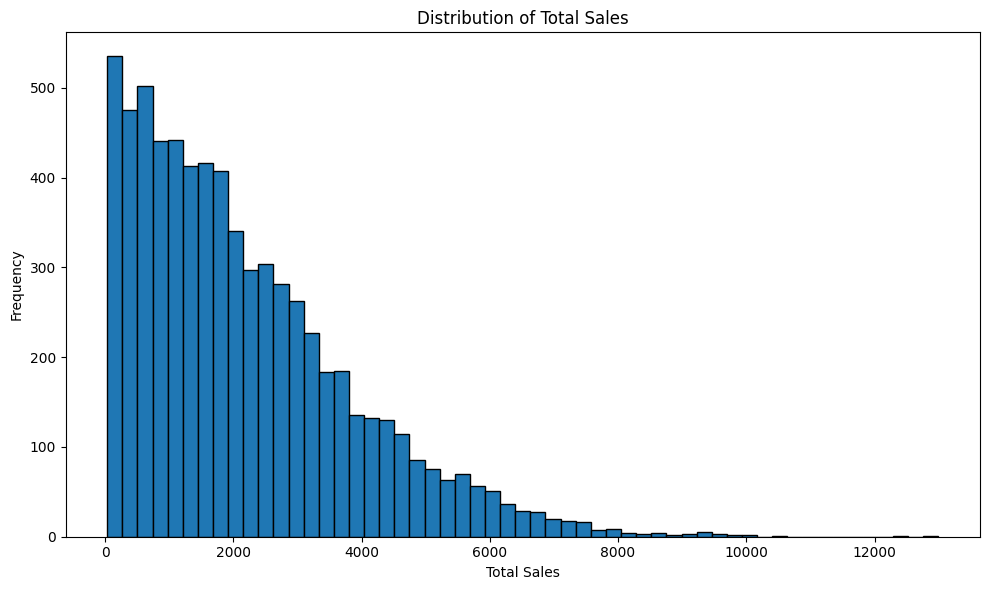

In [300]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    target,
    bins="fd",
    edgecolor="black"
)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("../Gallery/target_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

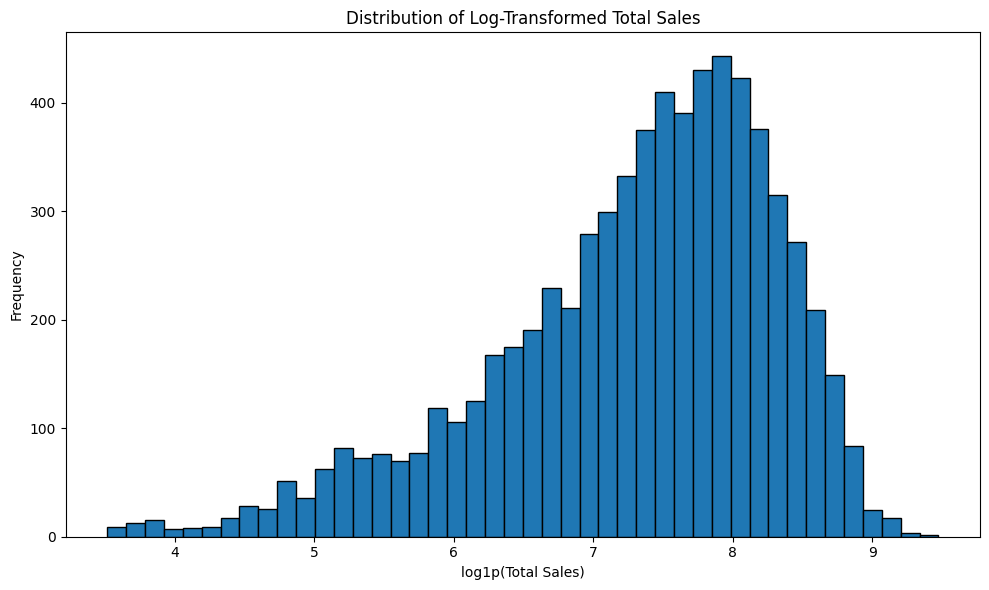

In [301]:
# Log-transformed target distribution

log_target = np.log1p(target)

plt.figure(figsize=(10, 6))

plt.hist(
    log_target,
    bins="fd",
    edgecolor="black"
)

plt.title("Distribution of Log-Transformed Total Sales")
plt.xlabel("log1p(Total Sales)")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("../Gallery/log_target_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [302]:
# Compare raw and log-transformed target distributions statistically

target_distribution_comparison = pd.DataFrame({
    "Raw total_sales": [
        target.mean(),
        target.std(),
        target.skew(),
        target.kurt(),
        target.quantile(0.01),
        target.quantile(0.50),
        target.quantile(0.99)
    ],
    "Log1p total_sales": [
        log_target.mean(),
        log_target.std(),
        log_target.skew(),
        log_target.kurt(),
        log_target.quantile(0.01),
        log_target.quantile(0.50),
        log_target.quantile(0.99)
    ]
}, index=[
    "Mean",
    "Std",
    "Skewness",
    "Kurtosis",
    "1st percentile",
    "Median",
    "99th percentile"
])

target_distribution_comparison

,Raw total_sales,Log1p total_sales
Mean,2174.756574,7.294273
Std,1697.894956,1.017638
Skewness,1.153995,-0.895128
Kurtosis,1.502748,0.576677
1st percentile,81.201700,4.409176
Median,1790.890000,7.491026
99th percentile,7261.389300,8.890464


In [303]:
# Target concentration across sales quantiles

target_bins = pd.qcut(
    target,
    q=[0, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00],
    duplicates="drop"
)

target_tail_summary = (
    train.groupby(target_bins, observed=True)["total_sales"]
    .agg(
        count="size",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
)

target_tail_summary

,count,mean,median,min,max
total_sales,,,,,
"(32.699000000000005, 1790.89]",3409,866.849196,834.740,32.70,1790.52
"(1790.89, 3092.587]",1704,2394.635241,2380.145,1791.26,3092.25
"(3092.587, 4557.841]",1023,3737.734633,3694.000,3092.70,4557.16
"(4557.841, 5557.191]",341,5003.998886,4978.640,4559.43,5556.57
"(5557.191, 7261.389]",272,6195.041691,6120.845,5560.71,7254.99
"(7261.389, 12996.82]",69,8359.789420,7986.050,7262.70,12996.82


In [304]:
# Contribution of each target region to total observed sales

target_mass = (
    train.groupby(target_bins, observed=True)["total_sales"]
    .agg(
        count="size",
        total_sales="sum"
    )
)

target_mass["observation_share"] = (
    target_mass["count"] / len(train)
)

target_mass["sales_share"] = (
    target_mass["total_sales"] / target.sum()
)

target_mass

,count,total_sales,observation_share,sales_share
total_sales,,,,
"(32.699000000000005, 1790.89]",3409,2955088.91,0.500000,0.199298
"(1790.89, 3092.587]",1704,4080458.45,0.249927,0.275195
"(3092.587, 4557.841]",1023,3823702.53,0.150044,0.257879
"(4557.841, 5557.191]",341,1706363.62,0.050015,0.115081
"(5557.191, 7261.389]",272,1685051.34,0.039894,0.113644
"(7261.389, 12996.82]",69,576825.47,0.010120,0.038902


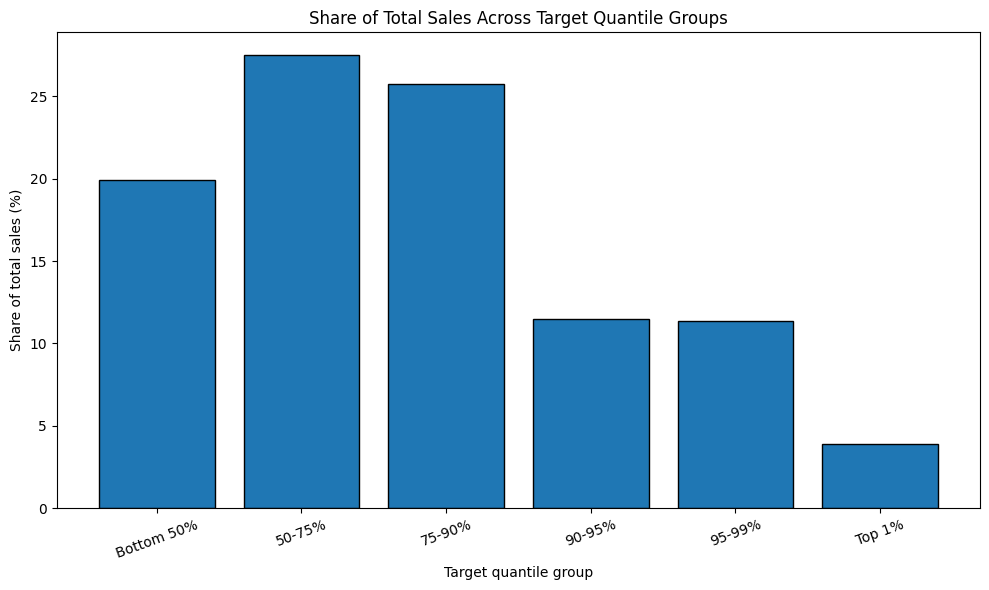

In [305]:
# Prepare target-mass data for plotting

plot_data = (
    target_mass
    .rename_axis("target_group")
    .reset_index()
)

labels = [
    "Bottom 50%",
    "50-75%",
    "75-90%",
    "90-95%",
    "95-99%",
    "Top 1%"
]

plot_data["target_group_label"] = labels

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["target_group_label"],
    plot_data["sales_share"] * 100,
    edgecolor="black"
)

plt.title("Share of Total Sales Across Target Quantile Groups")
plt.xlabel("Target quantile group")
plt.ylabel("Share of total sales (%)")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "../Gallery/target_sales_mass_by_quantile.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Target Variable Findings

The target variable `total_sales` exhibits substantial positive
skewness and dispersion.

- Mean sales are approximately 2,174.76, compared with a median of
  approximately 1,790.89.
- The raw target has skewness of approximately 1.15, confirming a
  pronounced right-skewed distribution.
- The standard deviation is approximately 1,697.89, giving a
  coefficient of variation of approximately 0.78.
- The upper tail extends to approximately 12,996.82, although only
  about 1% of observations exceed 7,261.
- The upper half of observations accounts for approximately 80% of
  the total observed sales value, while the lower half accounts for
  approximately 20%.
- The top 10% of observations account for approximately 26.8% of
  total observed sales.

Applying `log1p` substantially reduces the original positive
skewness, but produces moderate negative skewness rather than a
symmetric distribution. Therefore, the log transformation should not
be assumed to be superior based on distributional shape alone.

### Modeling implications

The target distribution motivates several hypotheses for later
experiments:

1. Raw-target and log-target models should both be evaluated.
2. Evaluation must remain on the original sales scale using RMSE.
3. Model residuals should later be examined across target quantiles.
4. Particular attention should be given to systematic
   underprediction or overprediction in the upper tail.
5. Target transformation should be treated as an empirical modeling
   decision rather than a preprocessing requirement.

In [306]:
# Statistical profile of product_price

price = train["product_price"]

price_summary = pd.Series({
    "count": price.count(),
    "mean": price.mean(),
    "median": price.median(),
    "std": price.std(),
    "variance": price.var(),
    "min": price.min(),
    "1%": price.quantile(0.01),
    "5%": price.quantile(0.05),
    "25%": price.quantile(0.25),
    "50%": price.quantile(0.50),
    "75%": price.quantile(0.75),
    "95%": price.quantile(0.95),
    "99%": price.quantile(0.99),
    "max": price.max(),
    "skewness": price.skew(),
    "kurtosis": price.kurt(),
    "iqr": price.quantile(0.75) - price.quantile(0.25),
    "coefficient_of_variation": price.std() / price.mean(),
    "unique_values": price.nunique()
})

price_summary

count                       6818.000000
mean                         140.473623
median                       142.065000
std                           62.413513
variance                    3895.446618
min                           31.110000
1%                            35.042100
5%                            42.135500
25%                           93.280000
50%                          142.065000
75%                          185.987500
95%                          250.116500
99%                          263.853000
max                          273.040000
skewness                       0.132447
kurtosis                      -0.897129
iqr                           92.707500
coefficient_of_variation       0.444308
unique_values               5818.000000
dtype: float64

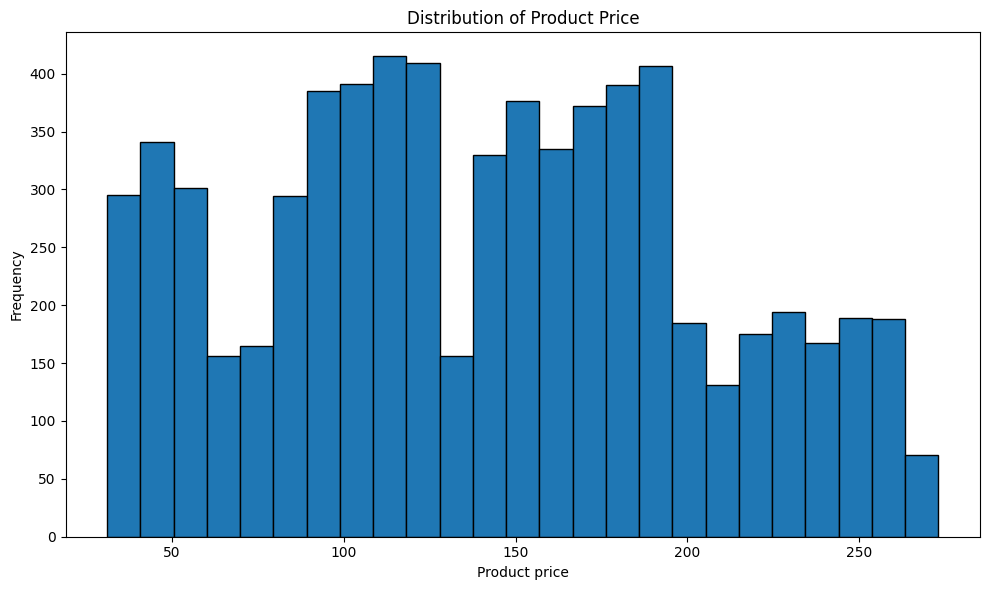

In [307]:
# Distribution of product_price

plt.figure(figsize=(10, 6))

plt.hist(
    train["product_price"],
    bins="fd",
    edgecolor="black"
)

plt.title("Distribution of Product Price")
plt.xlabel("Product price")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../Gallery/product_price_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [308]:
# Relationship between product price and total sales
# using price quantile bins

price_sales = train[["product_price", "total_sales"]].copy()

price_sales["price_quantile"] = pd.qcut(
    price_sales["product_price"],
    q=10,
    duplicates="drop"
)

price_sales_summary = (
    price_sales
    .groupby("price_quantile", observed=True)
    .agg(
        observations=("total_sales", "size"),
        mean_price=("product_price", "mean"),
        median_price=("product_price", "median"),
        mean_sales=("total_sales", "mean"),
        median_sales=("total_sales", "median"),
        std_sales=("total_sales", "std")
    )
)

price_sales_summary

,observations,mean_price,median_price,mean_sales,median_sales,std_sales
price_quantile,,,,,,
"(31.108999999999998, 51.83]",684,42.375541,42.160,625.416740,614.300,389.086218
"(51.83, 83.752]",680,66.622088,63.095,1030.650559,956.870,654.838054
"(83.752, 101.463]",682,93.014604,93.280,1446.364399,1402.310,841.797582
"(101.463, 117.848]",681,109.713642,109.930,1674.543715,1596.450,1025.510019
"(117.848, 142.065]",682,127.166994,125.410,1953.847639,1876.090,1170.645264
"(142.065, 158.83]",683,150.155578,149.890,2299.528902,2267.970,1336.130207
"(158.83, 177.744]",680,168.676794,168.930,2704.116162,2647.770,1523.913735
"(177.744, 194.228]",682,185.855748,185.985,2901.120132,2804.455,1815.793317
"(194.228, 230.835]",682,211.752434,212.895,3304.609340,3160.755,1915.844050


In [309]:
# Correlation between product price and total sales

price_sales_corr = pd.Series({
    "Pearson": train["product_price"].corr(
        train["total_sales"],
        method="pearson"
    ),
    "Spearman": train["product_price"].corr(
        train["total_sales"],
        method="spearman"
    )
})

price_sales_corr

Pearson     0.569833
Spearman    0.566437
dtype: float64

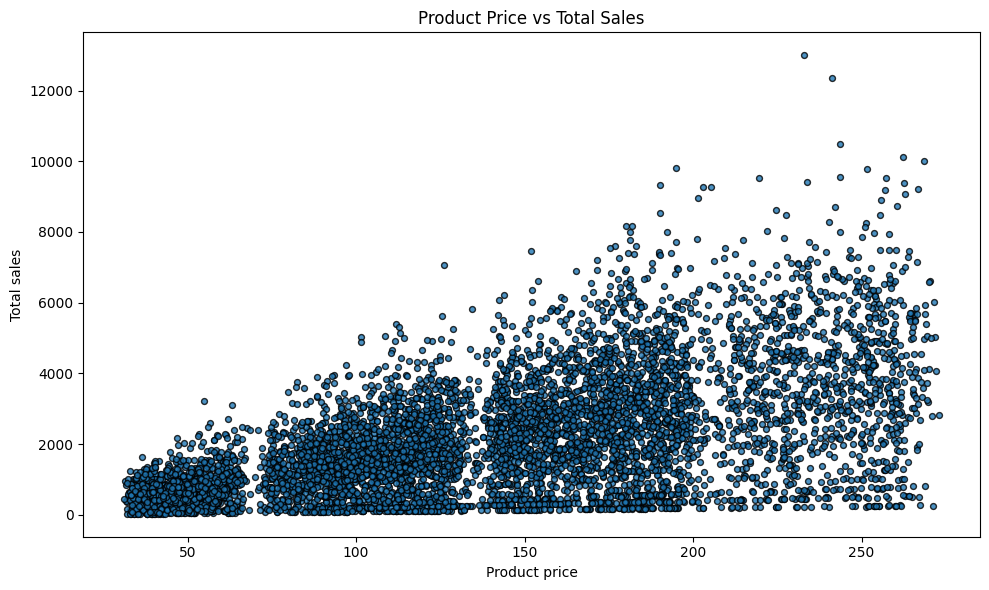

In [310]:
# Product price vs total sales

plt.figure(figsize=(10, 6))

plt.scatter(
    train["product_price"],
    train["total_sales"],
    edgecolor = "black",
    alpha=0.8,
    s=18
)

plt.title("Product Price vs Total Sales")
plt.xlabel("Product price")
plt.ylabel("Total sales")

plt.tight_layout()

plt.savefig(
    "../Gallery/product_price_vs_total_sales.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [311]:
# Product category sales profile

category_sales = (
    train
    .groupby("product_category")["total_sales"]
    .agg(
        observations="count",
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
        min_sales="min",
        max_sales="max"
    )
    .sort_values("mean_sales", ascending=False)
)

category_sales

,observations,mean_sales,median_sales,std_sales,min_sales,max_sales
product_category,,,,,,
seafood,14,2837.669286,2683.005,2166.050850,179.87,6393.58
STARCHY FOODS,30,2419.785333,2049.325,1768.174333,169.74,6898.82
Starchy Foods,59,2404.877627,2037.090,1656.753099,60.14,7222.03
starchy foods,24,2399.619167,1960.055,1961.053321,97.77,6161.08
FRUITS AND VEGETABLES,261,2381.811379,1873.450,1856.298062,60.92,9564.04
dairy,142,2374.590141,1796.840,1937.573686,47.83,9523.15
Meat,157,2372.897261,1883.860,1869.289999,46.46,9403.18
fruits and vegetables,265,2328.098868,1961.090,1760.319230,54.93,9388.15
canned,129,2309.617132,1894.880,1565.956903,37.76,6720.44


In [312]:
# Normalize product category casing

train["product_category_clean"] = train["product_category"].str.strip().str.lower()
test["product_category_clean"] = test["product_category"].str.strip().str.lower()

print("Unique raw categories  :", train["product_category"].nunique())
print("Unique cleaned categories:", train["product_category_clean"].nunique())

print("\nCleaned categories:")
print(sorted(train["product_category_clean"].unique()))

Unique raw categories  : 48
Unique cleaned categories: 16

Cleaned categories:
['baking goods', 'breads', 'breakfast', 'canned', 'dairy', 'frozen foods', 'fruits and vegetables', 'hard drinks', 'health and hygiene', 'household', 'meat', 'others', 'seafood', 'snack foods', 'soft drinks', 'starchy foods']


In [313]:
category_sales_clean = (
    train
    .groupby("product_category_clean")["total_sales"]
    .agg(
        observations="count",
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
        min_sales="min",
        max_sales="max"
    )
    .sort_values("mean_sales", ascending=False)
)

category_sales_clean

,observations,mean_sales,median_sales,std_sales,min_sales,max_sales
product_category_clean,,,,,,
starchy foods,113,2407.718584,2037.090,1738.033509,60.14,7222.03
household,740,2292.464662,2023.745,1719.283849,34.79,12996.82
fruits and vegetables,1006,2277.854672,1816.565,1785.736216,46.65,12359.04
meat,339,2264.310383,1861.450,1759.505669,46.46,9403.18
seafood,52,2262.524231,1929.040,1831.562938,150.90,6393.58
dairy,554,2238.317076,1695.955,1841.244799,40.12,10477.97
snack foods,933,2223.830568,1887.240,1629.473695,32.70,9323.55
canned,517,2196.398743,1838.800,1618.732859,37.76,8247.44
hard drinks,169,2189.723195,1842.880,1646.256984,37.80,8141.49


In [314]:
category_price_corr = (
    train
    .groupby("product_category_clean")
    .agg(
        observations=("total_sales", "size"),
        pearson_corr=("product_price", lambda x: x.corr(
            train.loc[x.index, "total_sales"], method="pearson"
        )),
        spearman_corr=("product_price", lambda x: x.corr(
            train.loc[x.index, "total_sales"], method="spearman"
        ))
    )
    .sort_values("pearson_corr", ascending=False)
)

category_price_corr

,observations,pearson_corr,spearman_corr
product_category_clean,,,
frozen foods,675,0.623552,0.625076
baking goods,516,0.606483,0.575809
hard drinks,169,0.600816,0.616461
canned,517,0.597569,0.588199
dairy,554,0.588729,0.600939
health and hygiene,412,0.585225,0.564772
fruits and vegetables,1006,0.577114,0.573514
seafood,52,0.570001,0.523521
meat,339,0.565322,0.564706


In [315]:
price_category_bins = (
    train
    .assign(
        price_bin=pd.qcut(
            train["product_price"],
            q=5,
            duplicates="drop"
        )
    )
    .groupby(
        ["product_category_clean", "price_bin"],
        observed=True
    )
    .agg(
        observations=("total_sales", "size"),
        median_sales=("total_sales", "median"),
        mean_sales=("total_sales", "mean")
    )
    .reset_index()
)

price_category_bins.head(20)

,product_category_clean,price_bin,observations,median_sales,mean_sales
0,baking goods,"(31.108999999999998, 83.752]",133,743.920,874.370602
1,baking goods,"(83.752, 117.848]",142,1540.670,1517.062535
2,baking goods,"(117.848, 158.83]",79,1853.640,2051.770886
3,baking goods,"(158.83, 194.228]",91,2838.160,2829.666044
4,baking goods,"(194.228, 273.04]",71,3445.250,3542.245352
5,breads,"(31.108999999999998, 83.752]",36,792.475,789.044722
6,breads,"(83.752, 117.848]",51,1768.130,1727.673922
7,breads,"(117.848, 158.83]",42,2108.500,2203.748095
8,breads,"(158.83, 194.228]",29,2545.410,2569.358966
9,breads,"(194.228, 273.04]",51,3394.720,3398.434118


In [316]:
# Compare median sales across global price bins for every product category
price_category_median = (
    price_category_bins
    .pivot(
        index="product_category_clean",
        columns="price_bin",
        values="median_sales"
    )
)

price_category_median

price_bin,"(31.108999999999998, 83.752]","(83.752, 117.848]","(117.848, 158.83]","(158.83, 194.228]","(194.228, 273.04]"
product_category_clean,,,,,
baking goods,743.920,1540.670,1853.640,2838.160,3445.250
breads,792.475,1768.130,2108.500,2545.410,3394.720
breakfast,511.165,1373.840,1390.610,2703.440,2686.110
canned,852.300,1525.900,2067.100,2782.790,3518.610
dairy,703.350,1278.100,1899.810,2812.660,3426.540
frozen foods,763.160,1651.395,1932.320,2575.000,3561.860
fruits and vegetables,806.050,1339.250,2224.110,2677.470,3560.395
hard drinks,753.090,1654.335,1859.860,2945.890,3231.425
health and hygiene,664.735,1568.635,2346.200,2241.680,3468.660


In [317]:
# Identify category × price-bin groups with fewer than 20 observations
small_price_category_groups = (
    price_category_bins
    .loc[
        price_category_bins["observations"] < 20,
        ["product_category_clean", "price_bin", "observations", "median_sales", "mean_sales"]
    ]
    .sort_values(["product_category_clean", "observations"])
)

small_price_category_groups

,product_category_clean,price_bin,observations,median_sales,mean_sales
11,breakfast,"(83.752, 117.848]",9,1373.840,1359.773333
14,breakfast,"(194.228, 273.04]",11,2686.110,2918.940000
12,breakfast,"(117.848, 158.83]",16,1390.610,1317.790000
10,breakfast,"(31.108999999999998, 83.752]",18,511.165,562.136111
36,hard drinks,"(83.752, 117.848]",18,1654.335,1528.171111
59,others,"(194.228, 273.04]",19,3469.040,3162.017368
64,seafood,"(194.228, 273.04]",7,3667.140,3955.611429
62,seafood,"(117.848, 158.83]",8,2950.310,2866.663750
60,seafood,"(31.108999999999998, 83.752]",10,607.710,669.171000
61,seafood,"(83.752, 117.848]",10,1748.895,1523.620000


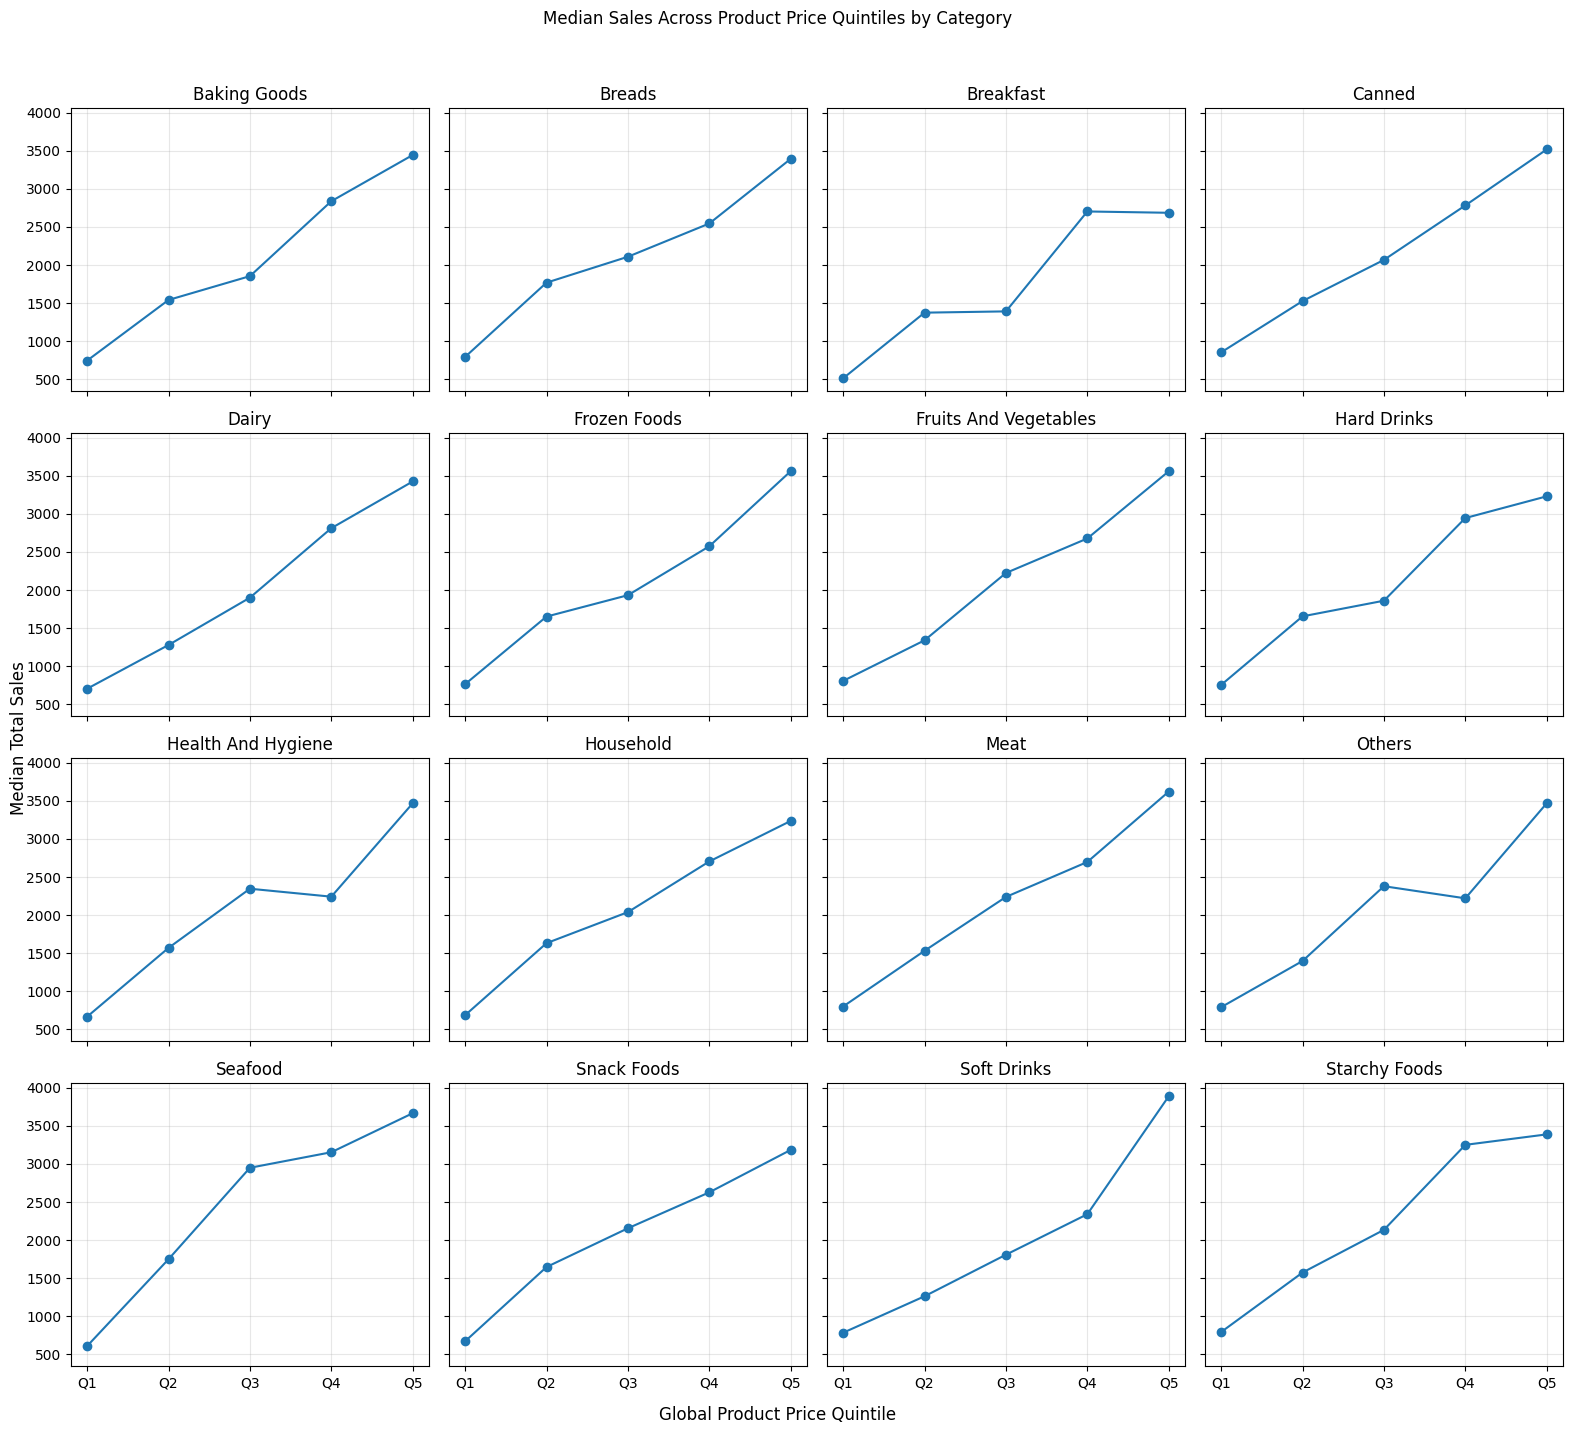

In [318]:
# Visualize median sales across global price bins for each product category
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(16, 14), sharex=True, sharey=True)

for ax, category in zip(axes.flat, price_category_median.index):
    values = price_category_median.loc[category]
    ax.plot(range(1, len(values) + 1), values.values, marker="o")
    ax.set_title(category.title())
    ax.set_xticks(range(1, len(values) + 1))
    ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4", "Q5"])
    ax.grid(alpha=0.3)

fig.supxlabel("Global Product Price Quintile")
fig.supylabel("Median Total Sales")
fig.suptitle("Median Sales Across Product Price Quintiles by Category", y=1.02)
plt.tight_layout()

plt.savefig("../Gallery/price_category_median_sales.png", dpi=300, bbox_inches="tight")
plt.show()

In [319]:
# Programmatically validate the main visual claims from the category price-quintile plot
plot_validation = price_category_median.copy()

plot_validation["Q1_to_Q5_change"] = plot_validation.iloc[:, -1] - plot_validation.iloc[:, 0]
plot_validation["Q1_to_Q5_ratio"] = plot_validation.iloc[:, -1] / plot_validation.iloc[:, 0]

plot_validation["monotonic_increase"] = (
    plot_validation.iloc[:, :5]
    .diff(axis=1)
    .iloc[:, 1:]
    .ge(0)
    .all(axis=1)
)

plot_validation["largest_jump"] = (
    plot_validation.iloc[:, :5]
    .diff(axis=1)
    .iloc[:, 1:]
    .idxmax(axis=1)
)

plot_validation[
    [
        "Q1_to_Q5_change",
        "Q1_to_Q5_ratio",
        "monotonic_increase",
        "largest_jump"
    ]
].sort_values("Q1_to_Q5_change", ascending=False)

price_bin,Q1_to_Q5_change,Q1_to_Q5_ratio,monotonic_increase,largest_jump
product_category_clean,,,,
soft drinks,3106.645,3.967973,True,"(194.228, 273.04]"
seafood,3059.430,5.034358,True,"(117.848, 158.83]"
meat,2823.375,3.535140,True,"(194.228, 273.04]"
health and hygiene,2803.925,4.218109,False,"(194.228, 273.04]"
frozen foods,2798.700,3.667252,True,"(194.228, 273.04]"
fruits and vegetables,2754.345,3.417090,True,"(117.848, 158.83]"
dairy,2723.190,3.871742,True,"(158.83, 194.228]"
baking goods,2701.330,3.631210,True,"(158.83, 194.228]"
others,2679.540,3.393971,False,"(194.228, 273.04]"


In [320]:
# Compare total_sales distributions across individual stores using summary statistics
store_sales_profile = (
    train
    .groupby("store_code")
    .agg(
        observations=("total_sales", "size"),
        mean_sales=("total_sales", "mean"),
        median_sales=("total_sales", "median"),
        std_sales=("total_sales", "std"),
        min_sales=("total_sales", "min"),
        max_sales=("total_sales", "max")
    )
    .sort_values("mean_sales", ascending=False)
)

store_sales_profile

,observations,mean_sales,median_sales,std_sales,min_sales,max_sales
store_code,,,,,,
STORE-7WS,748,3660.182219,3348.085,2070.097702,243.24,12996.82
STORE-9RG,752,2479.168098,2139.320,1553.797046,117.76,8726.50
STORE-89Z,728,2365.926745,2003.490,1518.177714,155.47,7477.67
STORE-OYG,744,2365.833656,2018.895,1566.741909,149.73,10130.90
STORE-AGY,748,2254.890120,1998.725,1501.401983,72.28,8141.49
STORE-YLW,754,2253.950690,1902.455,1488.222137,164.83,9999.51
STORE-DKU,736,2177.136481,1863.030,1446.586133,147.20,9388.15
STORE-HL7,742,1971.661954,1622.170,1397.518220,73.54,7016.22
STORE-T5G,427,338.326651,260.820,254.819146,32.70,1523.62


In [321]:
# Show the distribution of store formats within each store code
store_format_by_code = (
    pd.crosstab(
        train["store_code"],
        train["store_format"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

store_format_by_code

store_format,Corner Shop,Flagship Hypermarket,Standard Supermarket,Superstore
store_code,,,,
STORE-7WS,0.0,100.0,0.0,0.0
STORE-89Z,0.0,0.0,100.0,0.0
STORE-9RG,0.0,0.0,100.0,0.0
STORE-AGY,0.0,0.0,100.0,0.0
STORE-DKU,0.0,0.0,100.0,0.0
STORE-HL7,0.0,0.0,0.0,100.0
STORE-JOR,100.0,0.0,0.0,0.0
STORE-OYG,0.0,0.0,100.0,0.0
STORE-T5G,100.0,0.0,0.0,0.0


In [322]:
store_structure = (
    train
    .groupby("store_code")
    .agg(
        observations=("store_code", "size"),
        formats=("store_format", "nunique"),
        sizes=("store_size", "nunique"),
        location_tiers=("store_location_tier", "nunique"),
        ages=("store_age_years", "nunique")
    )
)

store_structure

,observations,formats,sizes,location_tiers,ages
store_code,,,,,
STORE-7WS,748,1,1,1,1
STORE-89Z,728,1,1,1,1
STORE-9RG,752,1,1,1,1
STORE-AGY,748,1,1,1,1
STORE-DKU,736,1,0,1,1
STORE-HL7,742,1,1,1,1
STORE-JOR,439,1,0,1,1
STORE-OYG,744,1,0,1,1
STORE-T5G,427,1,1,1,1


In [323]:
store_profile = (
    train
    .groupby("store_code")
    .agg(
        observations=("store_code", "size"),
        store_format=("store_format", "first"),
        store_size=("store_size", lambda x: x.dropna().unique().tolist()),
        store_location_tier=("store_location_tier", "first"),
        store_age_years=("store_age_years", "first")
    )
)

store_profile

,observations,store_format,store_size,store_location_tier,store_age_years
store_code,,,,,
STORE-7WS,748,Flagship Hypermarket,[Medium],Tier_3,47
STORE-89Z,728,Standard Supermarket,[Medium],Tier_1,33
STORE-9RG,752,Standard Supermarket,[Small],Tier_2,28
STORE-AGY,748,Standard Supermarket,[Large],Tier_3,45
STORE-DKU,736,Standard Supermarket,[],Tier_2,30
STORE-HL7,742,Superstore,[Medium],Tier_3,23
STORE-JOR,439,Corner Shop,[],Tier_3,34
STORE-OYG,744,Standard Supermarket,[],Tier_2,25
STORE-T5G,427,Corner Shop,[Small],Tier_1,47


In [324]:
format_sales_profile = (
    train
    .groupby("store_format")["total_sales"]
    .agg(
        observations="count",
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
        min_sales="min",
        max_sales="max"
    )
    .sort_values("mean_sales", ascending=False)
)

format_sales_profile

,observations,mean_sales,median_sales,std_sales,min_sales,max_sales
store_format,,,,,,
Flagship Hypermarket,748,3660.182219,3348.085,2070.097702,243.24,12996.82
Standard Supermarket,4462,2316.319677,1998.270,1515.508566,72.28,10130.90
Superstore,742,1971.661954,1622.170,1397.518220,73.54,7016.22
Corner Shop,866,336.353868,252.150,265.203584,32.70,1830.37


In [325]:
size_sales_profile = (
    train
    .groupby("store_size", dropna=False)["total_sales"]
    .agg(
        observations="count",
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
        min_sales="min",
        max_sales="max"
    )
    .sort_values("mean_sales", ascending=False)
)

size_sales_profile

,observations,mean_sales,median_sales,std_sales,min_sales,max_sales
store_size,,,,,,
Medium,2218,2670.506826,2242.365,1837.626661,73.54,12996.82
Large,748,2254.890120,1998.725,1501.401983,72.28,8141.49
Small,1933,1918.405954,1557.960,1591.900156,32.70,9999.51
NaN,1919,1828.749171,1463.670,1561.944991,33.30,10130.90


In [326]:
# Summarize total_sales across store location tiers, including any missing tier values.
tier_sales_profile = (
    train
    .groupby("store_location_tier", dropna=False)["total_sales"]
    .agg(
        observations="count",
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
        min_sales="min",
        max_sales="max"
    )
    .sort_values("mean_sales", ascending=False)
)

tier_sales_profile

,observations,mean_sales,median_sales,std_sales,min_sales,max_sales
store_location_tier,,,,,,
Tier_2,2232,2341.795296,2014.52,1528.102355,117.76,10130.90
Tier_3,2677,2254.114400,1794.26,1886.265993,33.30,12996.82
Tier_1,1909,1868.171278,1455.21,1563.302794,32.70,9999.51


In [327]:
# Create weight quantile bins and explicitly allow a separate Missing category.
weight_sales = train[["product_weight_kg", "total_sales"]].copy()

weight_sales["weight_bin"] = pd.qcut(
    weight_sales["product_weight_kg"],
    q=10,
    duplicates="drop"
)

weight_sales["weight_bin"] = (
    weight_sales["weight_bin"]
    .cat.add_categories("Missing")
)

weight_sales.loc[
    weight_sales["product_weight_kg"].isna(),
    "weight_bin"
] = "Missing"

weight_sales_profile = (
    weight_sales
    .groupby("weight_bin", observed=False)["total_sales"]
    .agg(
        observations="count",
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
        min_sales="min",
        max_sales="max"
    )
)

weight_sales_profile

,observations,mean_sales,median_sales,std_sales,min_sales,max_sales
weight_bin,,,,,,
"(4.481, 6.689]",560,2031.313482,1751.53,1382.846453,40.40,8894.14
"(6.689, 8.092]",559,2077.701521,1641.22,1596.994240,34.56,9999.51
"(8.092, 9.369]",559,2014.390411,1657.02,1495.518141,34.79,8141.49
"(9.369, 11.058]",560,2199.472661,1832.69,1644.372801,33.30,9072.04
"(11.058, 12.647]",559,2123.991914,1865.91,1514.257506,37.00,10130.90
"(12.647, 14.404]",559,2191.749946,1835.48,1605.830982,41.85,8726.50
"(14.404, 16.023]",559,2149.387191,1811.74,1583.366187,37.87,7813.00
"(16.023, 17.654]",560,2052.104518,1653.60,1574.879674,39.63,9388.15
"(17.654, 19.411]",559,2231.555707,1953.06,1487.119858,46.46,8282.96


In [328]:
# Compare product-weight missingness across normalized product categories.
weight_missing_by_category = (
    train
    .assign(weight_missing=train["product_weight_kg"].isna())
    .groupby("product_category_clean")["weight_missing"]
    .agg(
        observations="size",
        missing_count="sum",
        missing_rate="mean"
    )
    .sort_values("missing_rate", ascending=False)
)

weight_missing_by_category

,observations,missing_count,missing_rate
product_category_clean,,,
seafood,52,13,0.250000
breads,209,45,0.215311
meat,339,66,0.194690
snack foods,933,174,0.186495
fruits and vegetables,1006,186,0.184891
health and hygiene,412,75,0.182039
others,132,24,0.181818
soft drinks,366,65,0.177596
canned,517,91,0.176015


In [329]:
# Classify each product_code by how consistently its product weight is missing.
weight_missing_by_product = (
    train
    .groupby("product_code")["product_weight_kg"]
    .agg(
        observations="size",
        missing_count=lambda x: x.isna().sum()
    )
)

weight_missing_by_product["missing_rate"] = (
    weight_missing_by_product["missing_count"]
    / weight_missing_by_product["observations"]
)

weight_missing_pattern = (
    weight_missing_by_product["missing_rate"]
    .map(
        lambda x: (
            "none_missing" if x == 0
            else "all_missing" if x == 1
            else "partially_missing"
        )
    )
    .value_counts()
    .rename_axis("missing_pattern")
    .to_frame("product_count")
)

weight_missing_pattern

,product_count
missing_pattern,
partially_missing,977
none_missing,570
all_missing,8


In [330]:
# Measure product-weight missingness within each store to see whether missingness has a store-level pattern.
weight_missing_by_store = (
    train
    .assign(weight_missing=train["product_weight_kg"].isna())
    .groupby("store_code")["weight_missing"]
    .agg(
        observations="size",
        missing_count="sum",
        missing_rate="mean"
    )
    .sort_values("missing_rate", ascending=False)
)

weight_missing_by_store

,observations,missing_count,missing_rate
store_code,,,
STORE-7WS,748,748,1.000000
STORE-T5G,427,427,1.000000
STORE-AGY,748,10,0.013369
STORE-89Z,728,9,0.012363
STORE-HL7,742,8,0.010782
STORE-YLW,754,8,0.010610
STORE-9RG,752,7,0.009309
STORE-DKU,736,5,0.006793
STORE-OYG,744,3,0.004032


In [331]:
# Compare observed product-weight distributions across stores using count, median, and spread.
weight_by_store = (
    train
    .groupby("store_code")["product_weight_kg"]
    .agg(
        observations="count",
        missing_count=lambda x: x.isna().sum(),
        median_weight="median",
        mean_weight="mean",
        std_weight="std",
        min_weight="min",
        max_weight="max"
    )
)

weight_by_store

,observations,missing_count,median_weight,mean_weight,std_weight,min_weight,max_weight
store_code,,,,,,,
STORE-7WS,0,748,NaN,NaN,NaN,NaN,NaN
STORE-89Z,719,9,12.7120,12.978488,4.631218,4.636,21.680
STORE-9RG,745,7,12.6940,12.879001,4.653035,4.548,21.393
STORE-AGY,738,10,12.8110,12.991958,4.672165,4.482,21.375
STORE-DKU,731,5,12.1200,12.370100,4.564837,4.499,21.412
STORE-HL7,734,8,12.7695,12.946845,4.701208,4.719,21.681
STORE-JOR,439,0,12.7580,12.991228,4.613099,4.735,21.668
STORE-OYG,741,3,12.5070,12.853042,4.550505,4.546,21.883
STORE-T5G,0,427,NaN,NaN,NaN,NaN,NaN


In [332]:
# Measure how much product_weight_kg varies within each product_code across its observed records.
weight_variation_by_product = (
    train
    .groupby("product_code")["product_weight_kg"]
    .agg(
        observations="size",
        observed_values="count",
        unique_weights="nunique",
        median_weight="median",
        min_weight="min",
        max_weight="max"
    )
)

weight_variation_by_product["weight_range"] = (
    weight_variation_by_product["max_weight"]
    - weight_variation_by_product["min_weight"]
)

weight_variation_by_product.describe()

,observations,observed_values,unique_weights,median_weight,min_weight,max_weight,weight_range
count,1555.000000,1555.000000,1555.000000,1547.000000,1547.000000,1547.000000,1547.000000
mean,4.384566,3.596785,3.587138,12.810008,12.611861,13.010917,0.399056
std,1.556328,1.396858,1.394728,4.657881,4.578316,4.733850,0.269817
min,1.000000,0.000000,0.000000,4.547000,4.482000,4.677000,0.000000
25%,3.000000,3.000000,3.000000,8.755750,8.626000,8.839000,0.195500
50%,4.000000,4.000000,4.000000,12.527500,12.331000,12.723000,0.363000
75%,5.000000,5.000000,5.000000,16.864500,16.538000,17.148500,0.581500
max,9.000000,8.000000,8.000000,21.681000,21.110000,21.883000,1.223000


In [333]:
# Count observed product-weight values available for products with partial missingness.
partial_weight_products = (
    weight_variation_by_product
    .loc[
        (weight_variation_by_product["observed_values"] > 0) &
        (weight_variation_by_product["observed_values"] < weight_variation_by_product["observations"])
    ]
)

partial_weight_products["observed_values"].value_counts().sort_index()


observed_values
1     55
2    158
3    244
4    256
5    178
6     73
7     12
8      1
Name: count, dtype: int64

In [334]:
# Compare within-product weight variation across different numbers of observed weight values.
weight_stability_by_count = (
    partial_weight_products
    .groupby("observed_values")["weight_range"]
    .agg(
        products="count",
        median_range="median",
        mean_range="mean",
        max_range="max"
    )
)

weight_stability_by_count

,products,median_range,mean_range,max_range
observed_values,,,,
1,55,0.0000,0.000000,0.000
2,158,0.1355,0.231538,1.013
3,244,0.3320,0.382348,1.065
4,256,0.4540,0.469426,1.181
5,178,0.5290,0.539287,1.160
6,73,0.5030,0.542274,1.119
7,12,0.6575,0.656833,1.009
8,1,0.9510,0.951000,0.951


In [335]:
# Inspect the eight products whose product weight is completely missing in the training data.
all_missing_weight_products = weight_missing_by_product.loc[
    weight_missing_by_product["missing_rate"] == 1
]

all_missing_weight_products

,observations,missing_count,missing_rate
product_code,,,
PRD-7JH2LK,1,1,1.0
PRD-8CL0LC,1,1,1.0
PRD-DH3TKZ,1,1,1.0
PRD-DQHDK3,1,1,1.0
PRD-M80O2R,1,1,1.0
PRD-MRKSQJ,1,1,1.0
PRD-NBDVPI,1,1,1.0
PRD-QIGCT2,1,1,1.0


In [336]:
visibility = train["shelf_visibility"]

visibility_summary = pd.Series({
    "count": visibility.count(),
    "missing": visibility.isna().sum(),
    "unique": visibility.nunique(),
    "mean": visibility.mean(),
    "median": visibility.median(),
    "std": visibility.std(),
    "min": visibility.min(),
    "max": visibility.max(),
    "skewness": visibility.skew(),
    "kurtosis": visibility.kurtosis(),
    "zeros": (visibility == 0).sum(),
    "zero_pct": (visibility == 0).mean() * 100
})

visibility_quantiles = visibility.quantile(
    [0.00, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

display(visibility_summary.to_frame("value"))
display(visibility_quantiles.to_frame("quantile"))

,value
count,6818.000000
missing,0.000000
unique,1732.000000
mean,0.065527
median,0.053200
std,0.051566
min,0.000000
max,0.320100
skewness,1.181639
kurtosis,1.716955


,quantile
0.00,0.000000
0.01,0.000000
0.05,0.000000
0.10,0.011500
0.25,0.026600
0.50,0.053200
0.75,0.093400
0.90,0.139830
0.95,0.163900
0.99,0.227311


,correlation
pearson,-0.118124
spearman,-0.105185


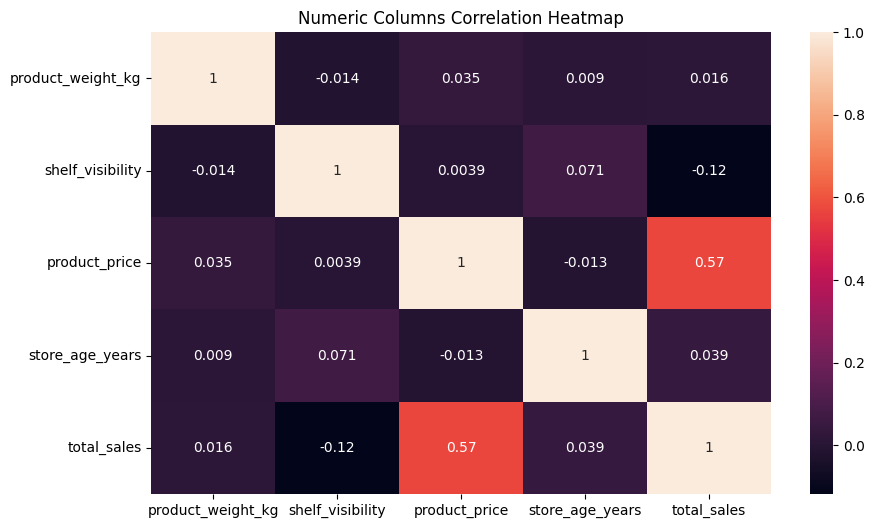

In [337]:
visibility_sales_corr = pd.Series({
    "pearson": train["shelf_visibility"].corr(train["total_sales"], method="pearson"),
    "spearman": train["shelf_visibility"].corr(train["total_sales"], method="spearman")
})

display(visibility_sales_corr.to_frame("correlation"))


import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = train.select_dtypes(include=["number"])
corr_matrix = numeric_cols.corr(method="pearson")
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,  
)

plt.title("Numeric Columns Correlation Heatmap")
plt.savefig("../Gallery/Numeric Columns Correlation Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


In [338]:
# Create visibility bins and summarize total_sales across them to check for nonlinear or regime-specific patterns.
visibility_sales = train[["shelf_visibility", "total_sales"]].copy()

visibility_sales["visibility_bin"] = pd.qcut(
    visibility_sales["shelf_visibility"],
    q=10,
    duplicates="drop"
)

visibility_sales_profile = (
    visibility_sales
    .groupby("visibility_bin", observed=True)["total_sales"]
    .agg(
        observations="count",
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
        min_sales="min",
        max_sales="max"
    )
    .reset_index()
)

display(visibility_sales_profile)

,visibility_bin,observations,mean_sales,median_sales,std_sales,min_sales,max_sales
0,"(-0.001, 0.0115]",683,2189.732577,1838.220,1595.636977,33.30,12996.82
1,"(0.0115, 0.022]",682,2345.404604,1950.685,1762.550278,80.42,12359.04
2,"(0.022, 0.0311]",682,2290.540557,2009.675,1616.827612,35.40,9803.38
3,"(0.0311, 0.041]",683,2366.624275,1932.320,1759.934920,60.92,10477.97
4,"(0.041, 0.0532]",683,2113.536003,1848.800,1581.991033,41.85,9768.51
5,"(0.0532, 0.0674]",679,2171.124080,1762.760,1706.692083,34.79,9999.51
6,"(0.0674, 0.0829]",680,2359.913426,1785.865,1915.006294,34.32,10130.90
7,"(0.0829, 0.106]",684,2249.370292,1873.005,1675.631412,54.93,9523.15
8,"(0.106, 0.14]",680,2067.929941,1727.510,1629.816931,32.70,7868.06
9,"(0.14, 0.32]",682,1593.171378,1051.540,1576.358414,34.56,9564.04


In [339]:
# Compare total_sales across within-category shelf-visibility quartiles to test whether the high-visibility pattern is consistent across product categories.
visibility_category = train[
    ["product_category_clean", "shelf_visibility", "total_sales"]
].copy()

visibility_category["visibility_quartile"] = (
    visibility_category
    .groupby("product_category_clean")["shelf_visibility"]
    .transform(
        lambda x: pd.qcut(x, q=4, labels=False, duplicates="drop") + 1
    )
)

visibility_category_profile = (
    visibility_category
    .groupby(
        ["product_category_clean", "visibility_quartile"],
        observed=True
    )["total_sales"]
    .agg(
        observations="count",
        mean_sales="mean",
        median_sales="median",
        std_sales="std"
    )
    .reset_index()
)

display(visibility_category_profile)

,product_category_clean,visibility_quartile,observations,mean_sales,median_sales,std_sales
0,baking goods,1,129,1956.625504,1546.930,1406.671145
1,baking goods,2,130,2091.770077,1721.440,1627.070832
2,baking goods,3,128,2181.095703,1814.130,1589.201737
3,baking goods,4,129,1544.868605,992.340,1471.324155
4,breads,1,53,2378.963396,2262.300,1692.511047
5,breads,2,52,2078.765385,1474.035,1728.522660
6,breads,3,52,2719.335385,2629.110,1660.416321
7,breads,4,52,1563.839423,1502.245,1165.117933
8,breakfast,1,22,2148.395000,1769.105,1759.499169
9,breakfast,2,21,1961.606667,1762.760,1352.803833


In [340]:
# Audit fat_content and summarize total_sales by fat-content group.
fat_content_summary = train.groupby("fat_content")["total_sales"].agg(
    observations="count",
    mean_sales="mean",
    median_sales="median",
    std_sales="std",
    min_sales="min",
    max_sales="max"
).round(2)

print("Value counts:")
print(train["fat_content"].value_counts(dropna=False))

print("\nSales profile by fat_content:")
display(fat_content_summary)

Value counts:
fat_content
Low Fat    4425
Regular    2393
Name: count, dtype: int64

Sales profile by fat_content:


,observations,mean_sales,median_sales,std_sales,min_sales,max_sales
fat_content,,,,,,
Low Fat,4425,2151.17,1761.1,1692.63,33.3,12996.82
Regular,2393,2218.38,1848.8,1707.08,32.7,12359.04


In [341]:
# Compare mean total_sales for Low Fat and Regular products within each cleaned product category.
fat_category_sales = (
    train.groupby(["product_category_clean", "fat_content"])["total_sales"]
    .agg(
        observations="count",
        mean_sales="mean",
        median_sales="median"
    )
    .round(2)
    .reset_index()
)

display(fat_category_sales)

,product_category_clean,fat_content,observations,mean_sales,median_sales
0,baking goods,Low Fat,263,1788.08,1447.51
1,baking goods,Regular,253,2104.90,1792.98
2,breads,Low Fat,121,2161.33,1780.02
3,breads,Regular,88,2220.29,2044.12
4,breakfast,Low Fat,30,1931.79,1537.35
5,breakfast,Regular,55,1808.79,1357.65
6,canned,Low Fat,265,2206.13,1775.68
7,canned,Regular,252,2186.16,1920.49
8,dairy,Low Fat,345,2143.75,1525.28
9,dairy,Regular,209,2394.43,2026.52


In [342]:
# Measure how fat_content is distributed within each cleaned product category.
fat_category_distribution = pd.crosstab(
    train["product_category_clean"],
    train["fat_content"],
    normalize="index"
).round(3)

display(fat_category_distribution)

fat_content,Low Fat,Regular
product_category_clean,,
baking goods,0.510,0.490
breads,0.579,0.421
breakfast,0.353,0.647
canned,0.513,0.487
dairy,0.623,0.377
frozen foods,0.530,0.470
fruits and vegetables,0.506,0.494
hard drinks,1.000,0.000
health and hygiene,1.000,0.000
